## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





[np.float64(70.0), np.float64(53.55450236966824), np.float64(53.510895883777245), np.float64(49.26829268292683), np.float64(52.876376988984084), np.float64(51.030421982335625), np.float64(46.6011466011466), np.float64(52.49472944483485), np.float64(49.41538461538462), np.float64(48.98741105637657), np.float64(50.02464268112371), np.float64(50.51546391752577), np.float64(50.143855322646935), np.float64(50.0), np.float64(50.17630465444288), np.float64(49.24292297564187), np.float64(49.074074074074076), np.float64(51.104009296920395), np.float64(50.46652030735456), np.float64(49.791991679667184), np.float64(49.35770750988142), np.float64(50.21176470588236), np.float64(50.06738544474394), np.float64(49.78513107004727), np.float64(49.81466227347611), np.float64(50.128534704370175), np.float64(51.35957406351017), np.float64(50.00915583226515), np.float64(51.262581670492665), np.float64(50.690537084398976), np.float64(50.65106312839954), np.float64(49.51347902376775), np.float64(49.7759233503

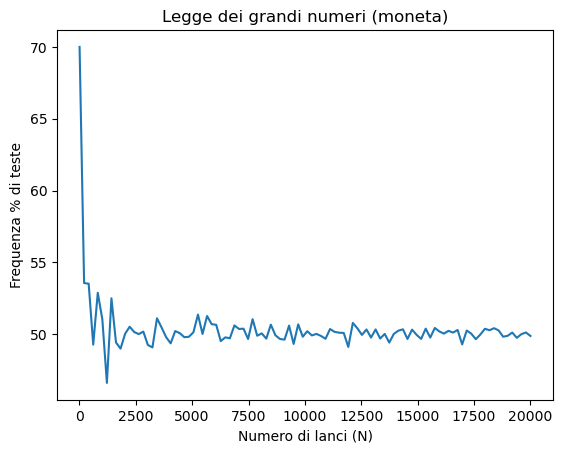

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# 1.
def coin_flip(N):
    heads_count = 0  
    for flip in range (N):
        result = random.randint(0,1)
        if result == 1:
            heads_count += 1

    heads_freq = (heads_count / N) * 100
    return heads_freq

# 2.
N_values = np.linspace(10, 20000, 100, dtype=int)

freq_values = [coin_flip(N) for N in N_values]
print(freq_values)

# 3.
sns.lineplot(x=N_values, y=freq_values)

plt.title("Legge dei grandi numeri (moneta)")
plt.xlabel("Numero di lanci (N)")
plt.ylabel("Frequenza % di teste")

plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [18]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# 1.
rows = df.shape[0]
cols = df.shape[1]
print(f"numero di righe: {rows}, numero di colonne: {cols}")
print("\n")

numero di righe: 891, numero di colonne: 12




In [20]:
# 2.
na_per_col = df.isnull().sum()
print("numero di NAN per colonna:\n",na_per_col)

numero di NAN per colonna:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [21]:
# 3.
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Embarked"].isnull().sum() # per verificare

np.int64(0)

In [22]:
# 4.
num = df.duplicated().sum()
print(f"ci sono {num} righe duplicate")

ci sono 0 righe duplicate


In [27]:
# 5.
df["Age"] = df["Age"].fillna(df["Age"].mean())
df.groupby("Pclass")["Age"].mean()

Pclass
1    37.048118
2    29.866958
3    26.403259
Name: Age, dtype: float64

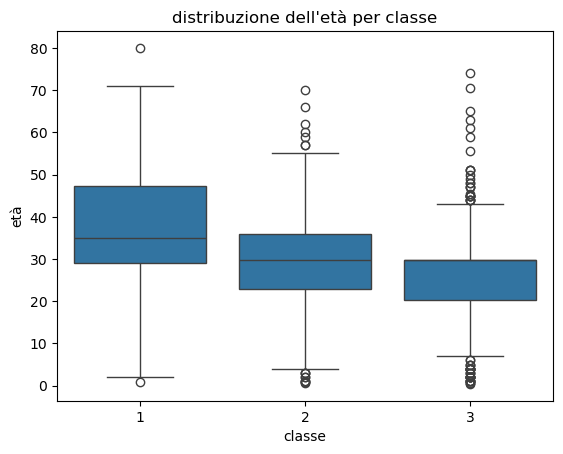

In [28]:
# 6.
sns.boxplot(data=df, x="Pclass", y="Age")
plt.title("distribuzione dell'età per classe")
plt.xlabel("classe")
plt.ylabel("età")
plt.show()

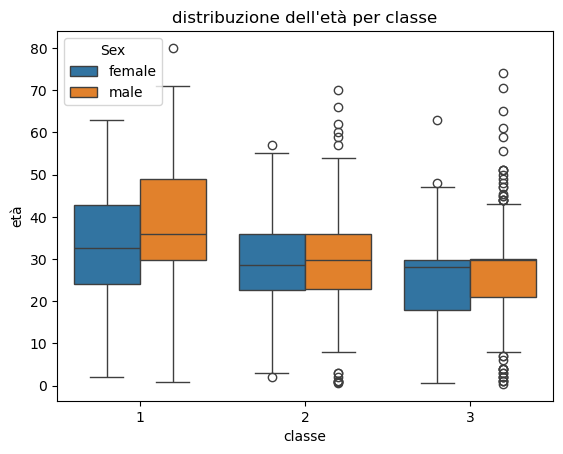

In [29]:
sns.boxplot(data=df, x="Pclass", y="Age", hue="Sex")
plt.title("distribuzione dell'età per classe")
plt.xlabel("classe")
plt.ylabel("età")
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [32]:
# 1.
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [ ]:
# 2.
df.groupby("species")[["petal_length", "petal_width"]].mean()

,petal_length,petal_width
species,,
setosa,1.462,0.246
versicolor,4.260,1.326
virginica,5.552,2.026


Text(0, 0.5, 'dimensione petali')

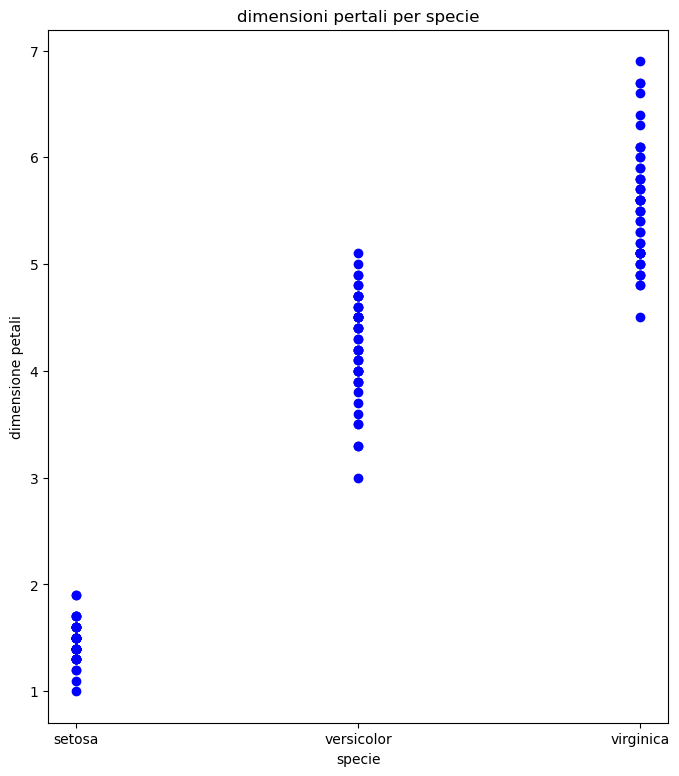

In [43]:
# 3.
plt.figure(figsize=(8,9))
plt.scatter(df["species"], df["petal_length"], color="blue")
plt.title("dimensioni pertali per specie")
plt.xlabel("specie")
plt.ylabel("dimensione petali")

In [46]:
# 4.
df["petal_area"] = df["petal_width"]*df["petal_length"]
area_mean = df["petal_area"].mean()
area_median = df["petal_area"].median()
area_mode = df["petal_area"].mode()
print(f"media delle aree: {area_mean}, mediana delle aree: {area_median}")
print(f"moda delle aree: {area_mode[0]}")

media delle aree: 5.794066666666667, mediana delle aree: 5.615
moda delle aree: 0.27999999999999997


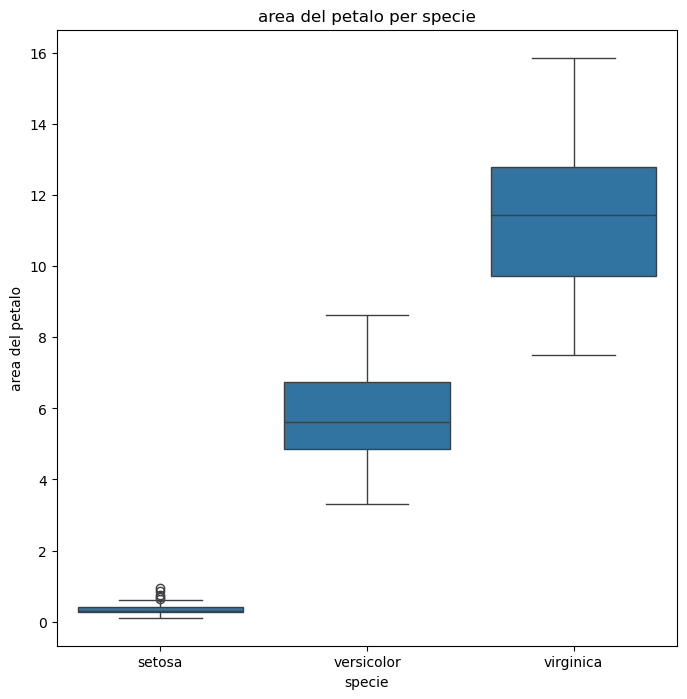

In [49]:
# 5.
plt.figure(figsize=(8,8))
sns.boxplot(data=df, x="species", y="petal_area")
plt.title("area del petalo per specie")
plt.xlabel("specie")
plt.ylabel("area del petalo")
plt.show()